# Modelling

We continue the analysing of data from Round 6 Multiple Indicator Cluster Surveys programme(MICS) focus on the urban area.

Our response variable is a binary indicator of whether a household is Moderate or Severe FI. In this notebook, we consider multilevel models to allow for and to explore between-community(clusters)
variance in Moderate or Severe. 

The data have a two-level hierarchical structure with 10,680 household at level 1, nested within 587 communities(clusters) at level 2. Since our focus is on Urban area, communities is refered to as neighborhood or clusters as defined in the survey design.

We consider a range of predictors. At level 1. We considered individual household variables. We used community level poverty/wealth index by aggregating household-level variables; this is a level 2 variable.


We conducted a preliminary check for multi-collinearity before constructing our multilevel models.

In [43]:
# Import the neccessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf
import statsmodels.api as sm

pd.set_option("display.max_columns", 500)
pd.set_option("display.max_row", 500)

In [96]:
# df = pd.read_csv("../processed_data/df2.csv")
df = pd.read_csv("../../../../mics6_cleaned_data.csv")


df.shape

(10680, 37)

In [97]:
df.head()


,hh1,zone,hhsex,hh_age_cat,hh_siz_cat,helevel,hh_own_dwelling,urban_wi_quintile_mics,hh_agricultural_land,hh_own_animal,hh_ag_land_size_cat,num_child_under5_cat,num_child_5_17_cat,WORRIED,HEALTHY,FEWFOOD,SKIPPED,ATELESS,RANOUT,HUNGRY,WHLDAY,fies_score,FI_Food_Insecure,SFI,MSI,FS,fies_0_3_7,prob_mod_sev,prob_sev,num_of_women_15_49_cat,num_of_men_15_49_cat,num_of_adults_cat,num_of_children_cat,num_of_men_attended_sch_cat,num_of_women_attended_sch_cat,hhweightmics,cluster_wi_category
0,1.0,South East,Female,>45,<5,Primary,RENT,Middle,NO,NO,0 hectare,No,1,1,1,1,1,1,1,1,0,7,1,1,1,0,3,0.995,0.390,2+,0,2+,1,0,2+,0.61955,High
1,1.0,South East,Female,36-45,<5,Senior secondary,RENT,Second,NO,NO,0 hectare,No,1,1,1,1,1,1,1,0,0,6,1,0,1,0,2,0.971,0.043,2+,0,2+,1,0,2+,0.61955,High
2,1.0,South East,Male,36-45,<5,Senior secondary,OWN,Middle,NO,YES,0 hectare,Yes,1,1,0,0,1,1,1,1,0,5,1,0,1,0,2,0.875,0.002,1,0,1,2+,0,1,0.61955,High
3,1.0,South East,Male,>45,<5,No Education,OWN,Poorest,YES,YES,1-9 hectares,No,0,0,1,1,1,1,1,1,1,7,1,1,1,0,3,0.995,0.390,1,1,2+,0,1,1,0.61955,High
4,1.0,South East,Male,>45,<5,Primary,RENT,Middle,NO,NO,0 hectare,No,1,1,1,1,1,1,1,1,0,7,1,1,1,0,3,0.995,0.390,1,0,1,1,0,1,0.61955,High


In [78]:
df.hh1.value_counts()

hh1
1842.0    20
1.0       20
2.0       20
3.0       20
1840.0    20
          ..
805.0     12
1823.0    11
614.0     11
1594.0    11
1179.0     9
Name: count, Length: 575, dtype: int64

## Model building strategy: Multilevel Logistic Regression Estimate (Multinominal Dependent variable)

<!-- To account for the categorical nature of our primary outcome variable `MSI`, which comprises
three levels displaying an intrinsic **ordinal hierarchy**, and that individual-level data is nested
within higher-level categories (i.e. clusters), we fitted a series of two-level random intercept
models to estimate the impact of **individual- and community-level** factors on food insecurity.


We employed a generalized linear mixed model with a multinomial distribution and the **CLO-
GIT** link function to compute the cumulative odds for each category of food insecurity.
This approach enabled us to account for the violation of the independence assumption and
avoid inflation of Type 1 errors. We used Statsmodel mixed effects logistic regression with maximum likelihood
with Laplace approximation (method = LAPLACE) and the CONTAIN method (DDFM = CONTAIN) to estimate the fixed effects as odds ratios (ORs) with 95% confidence
intervals (CIs) for the multilevel logistic regression estimates. 
 -->
The models fitted include;

* Null model: Model containing no predictors
* Model I: Model containing only individual-level predictors
* Model II: Model containing only community-level predictors
* Model III: Model containing both individual- and community-level predictors.


In [47]:
# # Prepare the output variables
# fi_mapping = {
#     "0-3": 1,
#     "4-6": 2,
#     "7-8": 3,
# }

# # Apply the mapping
# df["fies_0_3_7"] = df["fies_0_3_7"].map(fi_mapping)
# df.to_csv("../processed_data/df_r.csv", index=False)

In [98]:
## Import the function for importing R packages in Python

import os

os.environ["R_HOME"] = "/Library/Frameworks/R.framework/Resources"

# Import rpy2 only AFTER R_HOME is set
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.packages import importr
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri
import rpy2.robjects as ro

# Load the rpy2.ipython extension to use R magic commands in Jupyter notebooks
%load_ext rpy2.ipython
# pandas2ri.activate()

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [49]:
from rpy2.robjects.packages import importr

# # Install required R packages
# utils = importr("utils")

# # Install packages if not already installed
# utils.install_packages("tidyverse")
# utils.install_packages("gtsummary")
# utils.install_packages("lme4")
# utils.install_packages("jtools")
# utils.install_packages("car")
# utils.install_packages("VGAM")
# utils.install_packages("lattice")

# Now import them
tidyverse = importr("tidyverse")
base = importr("base")
dplyr = importr("dplyr")
gtsummary = importr("gtsummary")
lme4 = importr("lme4")
jtools = importr("jtools")
car = importr("car")


In [99]:
df.head()

,hh1,zone,hhsex,hh_age_cat,hh_siz_cat,helevel,hh_own_dwelling,urban_wi_quintile_mics,hh_agricultural_land,hh_own_animal,hh_ag_land_size_cat,num_child_under5_cat,num_child_5_17_cat,WORRIED,HEALTHY,FEWFOOD,SKIPPED,ATELESS,RANOUT,HUNGRY,WHLDAY,fies_score,FI_Food_Insecure,SFI,MSI,FS,fies_0_3_7,prob_mod_sev,prob_sev,num_of_women_15_49_cat,num_of_men_15_49_cat,num_of_adults_cat,num_of_children_cat,num_of_men_attended_sch_cat,num_of_women_attended_sch_cat,hhweightmics,cluster_wi_category
0,1.0,South East,Female,>45,<5,Primary,RENT,Middle,NO,NO,0 hectare,No,1,1,1,1,1,1,1,1,0,7,1,1,1,0,3,0.995,0.390,2+,0,2+,1,0,2+,0.61955,High
1,1.0,South East,Female,36-45,<5,Senior secondary,RENT,Second,NO,NO,0 hectare,No,1,1,1,1,1,1,1,0,0,6,1,0,1,0,2,0.971,0.043,2+,0,2+,1,0,2+,0.61955,High
2,1.0,South East,Male,36-45,<5,Senior secondary,OWN,Middle,NO,YES,0 hectare,Yes,1,1,0,0,1,1,1,1,0,5,1,0,1,0,2,0.875,0.002,1,0,1,2+,0,1,0.61955,High
3,1.0,South East,Male,>45,<5,No Education,OWN,Poorest,YES,YES,1-9 hectares,No,0,0,1,1,1,1,1,1,1,7,1,1,1,0,3,0.995,0.390,1,1,2+,0,1,1,0.61955,High
4,1.0,South East,Male,>45,<5,Primary,RENT,Middle,NO,NO,0 hectare,No,1,1,1,1,1,1,1,1,0,7,1,1,1,0,3,0.995,0.390,1,0,1,1,0,1,0.61955,High


#### Creating a community-level
The first step is to create the aggregated dataset using the community identifier,`hh1`.
To calculate the number of household in each community we need to calculate a
variable `nhousehold` coded 1 for all observations.

In [100]:
%%R
# Read in the data
data <- read_csv("../../../../mics6_cleaned_data.csv")

data$nhousehold <- rep(1, dim(data)[1])

mydata_agg <- aggregate(cbind(data$nhousehold), by = list(data$hh1), FUN = mean, na.rm =TRUE)

Rows: 10680 Columns: 37
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (19): zone, hhsex, hh_age_cat, hh_siz_cat, helevel, hh_own_dwelling, urb...
dbl (18): hh1, WORRIED, HEALTHY, FEWFOOD, SKIPPED, ATELESS, RANOUT, HUNGRY, ...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [101]:
%%R
# Read in the data
data <- read_csv("../../../../mics6_cleaned_data.csv")

# Relevel some variables
data$helevel <- factor(data$helevel, ordered = FALSE)
data$helevel <- relevel(data$helevel, ref = "No Education")

data$urban_wi_quintile_mics <- factor(data$urban_wi_quintile_mics,
                                      levels = c("Poorest","Second","Middle", "Fourth","Richest" ),
                                      ordered = FALSE)
data$urban_wi_quintile_mics <- relevel(data$urban_wi_quintile_mics, ref = "Poorest")

data$cluster_wi_category <- factor(data$cluster_wi_category,
                                   levels = c("Low", "Middle", "High"),
                                   ordered = FALSE)
data$cluster_wi_category <- relevel(data$cluster_wi_category, ref="Low")

# --- TASK 1: combine 'OTHER' and 'RENT' tenure into a single category ---
# Tenure originally has three levels (OWN, RENT, OTHER). RENT and OTHER are
# both "non-owner" arrangements, so we collapse them into one "Rent/Other"
# category and use OWN as the reference.
data$hh_own_dwelling <- as.character(data$hh_own_dwelling)
data$hh_own_dwelling[data$hh_own_dwelling %in% c("RENT", "OTHER")] <- "Rent/Other"
data$hh_own_dwelling <- factor(data$hh_own_dwelling, levels = c("OWN", "Rent/Other"))
data$hh_own_dwelling <- relevel(data$hh_own_dwelling, ref = "Rent/Other")

# Convert character and cluster column to factor
data <- data %>%
  mutate(across(where(is.character), as.factor))

# NOTE (TASK 4 fix): response variable is MSI (Moderate-or-Severe insecurity),
# which is the outcome used by every model below. The original code listed
# "MFI", a column that does not exist in the analysis data and is not the
# modelled response.
data <- data %>%
  mutate(across(c("SFI","FI_Food_Insecure", "MSI", "FS", "hh1" ), as.factor))


Rows: 10680 Columns: 37
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (19): zone, hhsex, hh_age_cat, hh_siz_cat, helevel, hh_own_dwelling, urb...
dbl (18): hh1, WORRIED, HEALTHY, FEWFOOD, SKIPPED, ATELESS, RANOUT, HUNGRY, ...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## Preliminary check: multicollinearity

Community poverty (`cluster_wi_category`) is **derived from the household wealth index**
(`urban_wi_quintile_mics`) by aggregating it to the cluster, so the two could be collinear.
We check this before building the multilevel models.

`car::vif()` reports the **generalised VIF (GVIF)** for categorical predictors. The comparable
quantity across terms is `GVIF^(1/(2*Df))`; squaring it lets us compare against the usual VIF
cut-off of ~5 (i.e. `GVIF^(1/(2*Df))` above ~2.24 is a concern).


In [102]:
%%R
# VIF computed on the single-level equivalent of the full fixed-effects model
vif_model <- glm(MSI ~ hhsex + hh_age_cat + hh_siz_cat + helevel +
                   hh_own_dwelling + urban_wi_quintile_mics +
                   hh_agricultural_land + hh_own_animal +
                   num_child_under5_cat + zone + cluster_wi_category,
                 family = binomial("logit"), data = data)
car::vif(vif_model)


                           GVIF Df GVIF^(1/(2*Df))
hhsex                  1.208191  1        1.099177
hh_age_cat             1.496199  3        1.069461
hh_siz_cat             1.372311  1        1.171457
helevel                1.935224  4        1.086029
hh_own_dwelling        1.340534  1        1.157815
urban_wi_quintile_mics 2.429275  4        1.117338
hh_agricultural_land   1.299396  1        1.139911
hh_own_animal          1.297045  1        1.138879
num_child_under5_cat   1.196086  1        1.093657
zone                   1.759536  5        1.058132
cluster_wi_category    1.842382  2        1.165051


### GVIF Results Table

| Predictor | GVIF | Df | GVIF^(1/(2*Df)) |
|---|---:|---:|---:|
| hhsex | 1.208191 | 1 | 1.099177 |
| hh_age_cat | 1.496199 | 3 | 1.069461 |
| hh_siz_cat | 1.372311 | 1 | 1.171457 |
| helevel | 1.935224 | 4 | 1.086029 |
| hh_own_dwelling | 1.340534 | 1 | 1.157815 |
| urban_wi_quintile_mics | 2.429275 | 4 | 1.117338 |
| hh_agricultural_land | 1.299396 | 1 | 1.139911 |
| hh_own_animal | 1.297045 | 1 | 1.138879 |
| num_child_under5_cat | 1.196086 | 1 | 1.093657 |
| zone | 1.759536 | 5 | 1.058132 |
| cluster_wi_category | 1.842382 | 2 | 1.165051 |

In [103]:
%%R
# Association between household wealth quintile and the derived community wealth
# (row-proportions). Shows the two are related but not redundant.
round(prop.table(table(data$urban_wi_quintile_mics, data$cluster_wi_category), 1), 3)


         
            Low Middle  High
  Poorest 0.100  0.545 0.355
  Second  0.000  0.263 0.737
  Middle  0.000  0.109 0.891
  Fourth  0.001  0.043 0.956
  Richest 0.000  0.013 0.987

**Interpretation.** Although community wealth is constructed from the household wealth index,
the adjusted GVIFs for both `urban_wi_quintile_mics` and `cluster_wi_category` stay well below the
conventional threshold (`GVIF^(1/(2*Df))` around 1.2–1.7, i.e. squared values well under 5). The
cross-tabulation confirms they are associated but not redundant: poorer households are more common
in low/middle-wealth communities, yet every quintile appears across community-wealth levels. We
therefore retain both variables in the models.


### **Important Methodology**

The estimation procedure optimizes a function of the log likelihood
using penalized iteratively re-weighted least squares. The log-likelihood is
evaluated using the **Laplacian approximation [ref](http://www.stat.columbia.edu/~cook/movabletype/archives/2010/09/r_vs_stata_or_d.html)**. This approximation method may
lead to unsatisfactory estimates....


In the glmer help file, it is noted that by specifying the option `nAGQ=n`, with n greater than 1,
changes the approximation method to adaptive **Gauss-Hermite approximation**, with a greater value
of n leading to more accurate evaluation of the log-likelihood. 
http://www.stat.columbia.edu/~cook/movabletype/archives/2010/09/r_vs_stata_or_d.html.

## 1.0 Specifying and estimating a two-level model

We will begin by fitting a null or empty two-level model, that is a model with only an intercept and community effects.


$$\log\left(\frac{\pi_{ij}}{1 - \pi_{ij}}\right) = \beta_j +  u_{oj}$$


The intercept $\beta_0$ is shared by all communities(clusters) while the random effect $u_{0j}$ is
specific to community $j$. The random effect is assumed to follow a normal
distribution with variance $\sigma^2_{u0}$


R’s main command for fitting multilevel models for binary and other discrete response variables is the glmer command 
which is part of an additional lme4 library[4](https://www.cmm.bris.ac.uk/lemma/mod/lesson/view.php?id=587&pageid=968#_ftn4). 

To fit the above model using the `glmer` command and to create a model object fit, we type:

In [104]:
%%R
#make this example reproducible
set.seed(7)

data$hh2 <- as.numeric(as.character(data$hh1))

fit <- glmer(MSI ~ (1|hh1),
             family = binomial("logit"),
             data = data,
             # nAGQ=25,
             weights = hhweightmics,
               )
summary(fit)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: MSI ~ (1 | hh1)
   Data: data
Weights: hhweightmics

      AIC       BIC    logLik -2*log(L)  df.resid 
  16937.7   16952.3   -8466.9   16933.7     10678 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-7.5626 -0.8030  0.4242  0.6575  3.2633 

Random effects:
 Groups Name        Variance Std.Dev.
 hh1    (Intercept) 0.5104   0.7144  
Number of obs: 10680, groups:  hh1, 575

Fixed effects:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  0.99462    0.03789   26.25   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In addition: Warning message:
In eval(family$initialize, rho) : non-integer #successes in a binomial glm!


The above model contains only an intercept and sno no fixed part explanatory variables are specifiied. The level two random part of the model is specified in brackets by the list of the random part explanatory variables

In [105]:
# VPC

0.5104 / (0.5104 + 3.29)

0.13430165245763603

$\sigma^2_{u0}$ => Variance of residual errors: the variance of the intercepts between the groups.

$\sigma^2_{e}$ => Variance of the lowest residual errors. We assume it is the same??

$\sigma^2_{u1}$ =>

$\sigma_{u01}$ => Covariance between the residual error terms, which is generally not aassumed to be zero.

**Deviance**: Indicates how well the model fits the data. Loweer deviance fit better than models with higher deviance.

ICC

## 2. Interpretation of the null two-level model

From the model estimates (using Laplacian approximation), we can say that the log-odds of being moderately or severely food insecure in an ‘average’ community (one with $u_{0j}$ = 0)
is estimated as $\beta_0$ = 0.99. The intercept for community 𝑗 is 0.99 + $u_{0j}$, where the variance of $u_{0j}$ is estimated as  $\sigma^2_{u0}$ = 0.5104.

The likelihood ratio statistic for testing the null hypothesis that $\sigma^2_{u0}$ = 0 can be calculated by comparing the two-level model, 
with the corresponding single-level model without the level 2 random effects.

In [106]:
%%R
fita <- glm(MSI ~ 1, data = data, weights =hhweightmics,  family = binomial("logit"))
logLik(fita)-logLik(fit)

'log Lik.' -848.7937 (df=1)


In addition: Warning message:
In eval(family$initialize) : non-integer #successes in a binomial glm!


In [107]:
-2 * (-848.7937)

1697.5874

The test statistic is 1697.5874 (-2*(-848.7937)) with 1 degree of freedom, so there is strong evidence that the between-community variance is non-zero.

In [108]:
%%R
anova(fit, fita, test="Chisq")

Data: data
Models:
fita: MSI ~ 1
fit: MSI ~ (1 | hh1)
     npar   AIC   BIC  logLik -2*log(L)  Chisq Df Pr(>Chisq)    
fita    1 18633 18641 -9315.6     18631                         
fit     2 16938 16952 -8466.9     16934 1697.6  1  < 2.2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


We will now examine estimates of the community effects or residuals, $\hat{u}_{0j}$,
obtained from the null model. Next, we will calculate the residuals and produce a
‘caterpillar plot’ with the community effects shown in rank order together with
95% confidence intervals we can us

In addition: Warning message:
In ranef.merMod(fit, postVar = TRUE) :
  ‘postVar’ is deprecated: please use ‘condVar’ instead


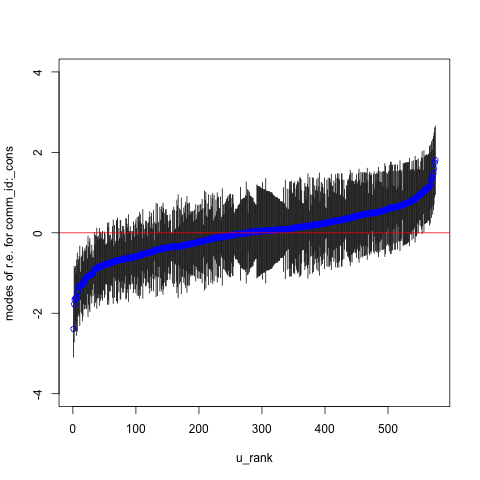

In [109]:
%%R
u0 <- ranef(fit, postVar = TRUE)
u0se <- sqrt(attr(u0[[1]], "postVar")[1, , ])
commid <- as.numeric(rownames(u0[[1]]))
u0tab <- cbind("commid" = commid, "u0" = u0[[1]], "u0se" = u0se)
colnames(u0tab)[2] <- "u0"
u0tab <- u0tab[order(u0tab$u0), ]
u0tab <- cbind(u0tab, c(1:dim(u0tab)[1]))
u0tab <- u0tab[order(u0tab$commid), ]
colnames(u0tab)[4] <- "u0rank" 

plot(u0tab$u0rank, u0tab$u0, type = "n", xlab = "u_rank", ylab = "conditional
modes of r.e. for comm_id:_cons", ylim = c(-4, 4)) 

segments(u0tab$u0rank, u0tab$u0 - 1.96*u0tab$u0se, u0tab$u0rank, u0tab$u0 +
           1.96*u0tab$u0se)
           
points(u0tab$u0rank, u0tab$u0, col = "blue")

abline(h = 0, col = "red")

In [138]:
%%R
summ(fit)
summ(fita, exp=T)

MODEL INFO:
Observations: 10680
Dependent Variable: MSI
Type: Generalized linear model
  Family: binomial 
  Link function: logit 

MODEL FIT:
χ²(0) = -0.00, p =  NA
Pseudo-R² (Cragg-Uhler) = 0.00
Pseudo-R² (McFadden) = 0.00
AIC = 18633.30, BIC = 18640.57 

Standard errors:MLE
------------------------------------------------------------
                    exp(Est.)   2.5%   97.5%   z val.      p
----------------- ----------- ------ ------- -------- ------
(Intercept)              2.44   2.36    2.53    50.51   0.00
------------------------------------------------------------


In addition: Warning message:
In eval(family$initialize) : non-integer #successes in a binomial glm!


The plot shows the estimated residuals for all 575 communities (clusters) in the sample (urban area). For
a substantial number of communities, the 95% confidence interval does not overlap
the horizontal line at zero, indicating that Moderate or Severe FI in these
communities is significantly above average (above the zero line) or below average
(below the zero line). 

## 3. Adding an explantory variable

Next we will include household head age as an explanatory variable in the model.


$$\log\left(\frac{\pi_{ij}}{1 - \pi_{ij}}\right) = \beta_0 + \beta_1hhage_{ij} +  u_{0j}$$



In [110]:
%%R
fit2 <- glmer(formula = MSI ~ hh_age_cat + (1|hh1),
             family = binomial("logit"),
             data = data,
             # nAGQ=25,
             weights = hhweightmics,
               )
summary(fit2)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: MSI ~ hh_age_cat + (1 | hh1)
   Data: data
Weights: hhweightmics

      AIC       BIC    logLik -2*log(L)  df.resid 
  16921.9   16958.3   -8456.0   16911.9     10675 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-8.0301 -0.8047  0.4209  0.6532  3.0830 

Random effects:
 Groups Name        Variance Std.Dev.
 hh1    (Intercept) 0.5097   0.714   
Number of obs: 10680, groups:  hh1, 575

Fixed effects:
                Estimate Std. Error z value Pr(>|z|)    
(Intercept)      0.91333    0.04214  21.675  < 2e-16 ***
hh_age_cat16-25  0.23861    0.09909   2.408   0.0160 *  
hh_age_cat26-35  0.09266    0.05319   1.742   0.0815 .  
hh_age_cat36-45  0.20161    0.04470   4.511 6.46e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr) h__16- h__26-
hh_g_c16-25 -0.179              


In addition: Warning message:
In eval(family$initialize, rho) : non-integer #successes in a binomial glm!


Note that there is little change in the estimate odd of the between-cluster variance, suggesting that the distribution of household head age is similar across communities (clusters).


The equation of the average fitted regression line, expressin the relationship between the log-odds being Moderate or Severe FI and household head age, is: 


$$\log\left(\frac{\pi_{ij}}{1 - \pi_{ij}}\right) = 1.15196 - 0.14596hhageYoung_{ij} -0.03701hhageMiddle_{ij} -0.23862hhageOld_{ij}$$

The fitted line for a given community(cluster) will differ from the average line in its
intercept, by an amount $\hat{u}{j}$ for community $j$. A plot of the predicted community
lines will therefore show a set of parallel lines. To produce this plot, we first need
to calculate the predicted log-odds of Moderate or Severe FI for each household based on
household head age at area and community of residence. 

To do this we compute the predicted probability of Moderate or Severe FI for each household using the `fitted`
command. 

In [112]:
%%R
library(VGAM)

In [111]:
%%R
predprob < -fitted(fit2, type="response")
predlogit < -qlogis(predprob)

    1     2     3     4     5     6     7     8     9    10    11    12    13 
FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE 
   14    15    16    17    18    19    20    21    22    23    24    25    26 
FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE 
   27    28    29    30    31    32    33    34    35    36    37    38    39 
FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE 
   40    41    42    43    44    45    46    47    48    49    50    51    52 
FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE 
   53    54    55    56    57    58    59    60    61    62    63    64    65 
FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE 
   66    67    68    69    70    71    72    73    74    75    76    77    78 
FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE 
   79    80    81    82    83    84    85    86    8

In [113]:
%%R
datapred <- unique(data.frame(cbind(predlogit = predlogit, comm = data$hh1, 
hh_age_cat = data$hh_age_cat)))

In [114]:
df.hh_age_cat.value_counts()

hh_age_cat
>45      5375
36-45    2948
26-35    1896
16-25     461
Name: count, dtype: int64

In [115]:
%%R
library(lattice)

xyplot(predlogit ~ hh_age_cat, data = datapred, groups = comm, type =  c("p", "l",
"g"), col = "blue")

nrow(data)

[1] 10680


For a household head aged 16-25, the log-odds of being moderately or severely food insecure ranges from about -0.3 to 3.0 depending on which community they lives in. This translates to a range in probabilities of exp(-0.3)/[1+ exp(-0.3)] = 0.43 , to exp(3.0)/[1+ exp(3.0)] = 0.95, so there are strong community effects

In [69]:
import math

math.exp(-0.3) / (1 + math.exp(-0.3))

0.425557483188341

In [70]:
math.exp(3.0) / (1 + math.exp(3.0))

0.9525741268224333

### Unadjusted (univariable) analysis

Before the adjusted multilevel models, we fit an **unadjusted** model for each predictor on its
own, retaining the community random intercept `(1 | hh1)`. This gives the crude (univariable) odds
ratios prior to any mutual adjustment, and is the standard companion to the adjusted estimates.


In [116]:
%%R

library(broom.helpers)

uv_tab <- tbl_uvregression(
  data = data,
  method = lme4::glmer,
  y = MSI,
  include = c(hhsex, hh_age_cat, hh_siz_cat, helevel, hh_own_dwelling,
              urban_wi_quintile_mics, hh_agricultural_land, hh_own_animal,
              num_child_under5_cat, zone, cluster_wi_category),
  formula = "{y} ~ {x} + (1 | hh1)",
  method.args = list(family = binomial, weights = hhweightmics),
  exponentiate = TRUE
) %>%
  modify_header(label = "**Predictor**") %>%
  bold_labels()

as_gt(uv_tab)


There was a warning constructing the model for variable "hhsex". See message
below.
! non-integer #successes in a binomial glm!
There was a warning constructing the model for variable "hh_age_cat". See
message below.
! non-integer #successes in a binomial glm!
There was a warning constructing the model for variable "hh_siz_cat". See
message below.
! non-integer #successes in a binomial glm!
There was a warning constructing the model for variable "helevel". See message
below.
! non-integer #successes in a binomial glm!
There was a warning constructing the model for variable "hh_own_dwelling". See
message below.
! non-integer #successes in a binomial glm!
There was a warning constructing the model for variable
"urban_wi_quintile_mics". See message below.
! non-integer #successes in a binomial glm!
There was a warning constructing the model for variable "hh_agricultural_land".
See message below.
! non-integer #successes in a binomial glm!
There was a warning constructing the model for var

### Model I: Model containing only individual/household-level predictors
Comparison of a single -level and multilevel threshold model.

The model fitted have allowed the probability of a household being moderate or severely food insecure to depend on the community of household(as well as individual household characteristics). This was acheived by allowing intercept to vary randomly across communities in a random intercept model.

We have assumed, however that the effects of individual household characteristics such as hh age are the same in each community, i.e the coefficient of all explanatory variables are fixed across communities.

In [117]:
%%R
#make this example reproducible
set.seed(7)

model1 <- glmer(formula = MSI ~ hhsex + hh_age_cat + hh_siz_cat  + 
    helevel + hh_own_dwelling + urban_wi_quintile_mics + hh_agricultural_land + 
    hh_own_animal + num_child_under5_cat +
    (1|hh1),
    family = binomial,
    data = data,
    # nAGQ=25,
    weights = hhweightmics,
    
)

In addition: Warning message:
In eval(family$initialize, rho) : non-integer #successes in a binomial glm!


In [118]:
%%R
summary(model1)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: MSI ~ hhsex + hh_age_cat + hh_siz_cat + helevel + hh_own_dwelling +  
    urban_wi_quintile_mics + hh_agricultural_land + hh_own_animal +  
    num_child_under5_cat + (1 | hh1)
   Data: data
Weights: hhweightmics

      AIC       BIC 

   logLik -2*log(L)  df.resid 
  15479.0   15617.3   -7720.5   15441.0     10661 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-9.5914 -0.6021  0.3390  0.6057  5.3660 

Random effects:
 Groups Name        Variance Std.Dev.
 hh1    (Intercept) 0.6307   0.7942  
Number of obs: 10680, groups:  hh1, 575

Fixed effects:
                                Estimate Std. Error z value Pr(>|z|)    
(Intercept)                    1.8091509  0.0893036  20.258  < 2e-16 ***
hhsexMale                      0.0289670  0.0538988   0.537 0.590968    
hh_age_cat16-25               -0.2250799  0.1083476  -2.077 0.037766 *  
hh_age_cat26-35                0.0005093  0.0636933   0.008 0.993620    
hh_age_cat36-45                0.1837103  0.0519426   3.537 0.000405 ***
hh_siz_cat>5                   0.3156793  0.0504096   6.262 3.79e-10 ***
helevelHigher/tertiary         0.1556816  0.0795737   1.956 0.050413 .  
helevelJunior secondary        0.4261585  0.1185914   3.594 0.000326 ***
helevelPri


Correlation matrix not shown by default, as p = 18 > 12.
Use print(object, correlation=TRUE)  or
    vcov(object)        if you need it



### **Variance partition coefficient**

The variance partition coefficient (VPC) is calculated as 
$$ \sqrt{\frac{\sigma^2_u}{\sigma^2_u + \sigma^2_e}} $$


In [119]:
# VPC
0.6293 / (0.6293 + 3.29)

0.16056438649758886

The variance partition coefficient (VPC) is calculated as 0.6293/(0.6293 + 3.29) = 0.16. Thus 16% of the residual variation in the propensity moderate or severe (y*) is attributable to unobserved community characteristics. 

In [120]:
%%R

summ(model1, exp=T)


MODEL INFO:
Observations: 10680
Dependent Variable: MSI
Type: Mixed effects generalized linear regression
Error Distribution: binomial
Link function: logit 

MODEL FIT:
AIC = 15479.01, BIC = 15617.25
Pseudo-R² (fixed effects) = 0.16
Pseudo-R² (total) = 0.30 

FIXED EFFECTS:
----------------------------------------------------------------------
                                      exp(Est.)   S.E.   z val.      p
----------------------------------- ----------- ------ -------- ------
(Intercept)                                6.11   0.09    20.26   0.00
hhsexMale                                  1.03   0.05     0.54   0.59
hh_age_cat16-25                            0.80   0.11    -2.08   0.04
hh_age_cat26-35                            1.00   0.06     0.01   0.99
hh_age_cat36-45                            1.20   0.05     3.54   0.00
hh_siz_cat>5                               1.37   0.05     6.26   0.00
helevelHigher/tertiary                     1.17   0.08     1.96   0.05
helevelJunior s

In [139]:
%%R
library(gtsummary)
#Create the summary table
summary_table <- tbl_regression(model1,
                                 exponentiate = TRUE,   # Convert coefficients to odds ratios
                                 conf.level = 0.95)   
print(summary_table)

### Model II: Model containing only Community-level predictors



In [122]:
%%R
set.seed(7)
model2 <- glmer(formula = MSI ~ zone+cluster_wi_category+(1|hh1),
    family = binomial,
    data = data,
    # nAGQ=25,
    weights = hhweightmics,
)

In addition: Warning message:
In eval(family$initialize, rho) : non-integer #successes in a binomial glm!


In [123]:
%%R
summary(model2)

Generalized linear mixed model fit by maximum likelihood (Laplace


  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: MSI ~ zone + cluster_wi_category + (1 | hh1)
   Data: data
Weights: hhweightmics

      AIC       BIC    logLik -2*log(L)  df.resid 
  16885.3   16950.8   -8433.6   16867.3     10671 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-7.6829 -0.8159  0.4132  0.6593  3.2033 

Random effects:
 Groups Name        Variance Std.Dev.
 hh1    (Intercept) 0.4238   0.651   
Number of obs: 10680, groups:  hh1, 575

Fixed effects:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)                 1.5128     0.2699   5.604 2.09e-08 ***
zoneNorth East             -0.7623     0.1464  -5.207 1.92e-07 ***
zoneNorth West             -0.4826     0.1355  -3.561 0.000369 ***
zoneSouth East              0.2287     0.1566   1.460 0.144344    
zoneSouth South            -0.3318     0.1357  -2.446 0.014457 *  
zoneSouth West             -0.5656     0.1078  -5.246 1.55e-07 ***
cluster_wi_categoryMiddle   0

In [124]:
# VPC
0.4238 / (0.4238 + 3.29)

0.11411492272066348

In [125]:
%%R
summ(model2, exp=T)

MODEL INFO:
Observations: 10680
Dependent Variable: MSI
Type: Mixed effects generalized linear regression
Error Distribution: binomial
Link function: logit 

MODEL FIT:
AIC = 16885.30, BIC = 16950.78
Pseudo-R² (fixed effects) = 0.03
Pseudo-R² (total) = 0.14 

FIXED EFFECTS:
------------------------------------------------------------------
                                  exp(Est.)   S.E.   z val.      p
------------------------------- ----------- ------ -------- ------
(Intercept)                            4.54   0.27     5.60   0.00
zoneNorth East                         0.47   0.15    -5.21   0.00
zoneNorth West                         0.62   0.14    -3.56   0.00
zoneSouth East                         1.26   0.16     1.46   0.14
zoneSouth South                        0.72   0.14    -2.45   0.01
zoneSouth West                         0.57   0.11    -5.25   0.00
cluster_wi_categoryMiddle              1.31   0.26     1.02   0.31
cluster_wi_categoryHigh                0.80   0.26    -

In [126]:
%%R

#Create the summary table
summary_table2 <- tbl_regression(model2,
                                 exponentiate = TRUE,   # Convert coefficients to odds ratios
                                 conf.level = 0.95)   
print(summary_table2)

### Model III: Combination of Community-level predictors and individual/household-level predictors

In [127]:
%%R
model3 <- glmer(formula = MSI ~ hhsex + hh_age_cat + hh_siz_cat  + 
            helevel + hh_own_dwelling + urban_wi_quintile_mics + 
            hh_agricultural_land + hh_own_animal + num_child_under5_cat+ 
            zone+cluster_wi_category+
            (1|hh1),
            family = binomial("logit"),
            # nAGQ=25,
            data = data,
            weights = hhweightmics,
)


In addition: Warning messages:
1: In eval(family$initialize, rho) :
  non-integer #successes in a binomial glm!
2: In (function (fn, par, lower = rep.int(-Inf, n), upper = rep.int(Inf,  :
  failure to converge in 10000 evaluations
3: In optwrap(optimizer, devfun, start, lower = lower, upper = upper,  :
  convergence code 4 from Nelder_Mead: failure to converge in 10000 evaluations


In [128]:
%%R
summary(model3)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: MSI ~ hhsex + hh_age_cat + hh_siz_cat + helevel + hh_own_dwelling +  
    urban_wi_quintile_mics + hh_agricultural_land + hh_own_animal +  
    num_child_under5_cat + zone + cluster_wi_category + (1 |      hh1)
   Data: data
Weights: hhweightmics

      AIC       BIC    logLik -2*log(L)  df.resid 
  15414.5   15603.6   -7681.2   15362.5     10654 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-9.8525 -0.6001  0.3448  0.6082  5.3219 

Random effects:
 Groups Name        Variance Std.Dev.
 hh1    (Intercept) 0.5186   0.7202  
Number of obs: 10680, groups:  hh1, 575

Fixed effects:
                              Estimate Std. Error z value Pr(>|z|)    
(Intercept)                    1.99431    0.30123   6.621 3.58e-11 ***
hhsexMale                      0.05198    0.05413   0.960 0.336917    
hh_age_cat16-25               -0.21850    0.10836  -2.


Correlation matrix not shown by default, as p = 25 > 12.
Use print(object, correlation=TRUE)  or
    vcov(object)        if you need it



#### Fixed-effects intercept: p-value

The p-value for the **fixed-effects intercept** of the full model (Model III) is extracted and
highlighted below. In the current fit it is `Pr(>|z|) = 9.79e-07` (estimate = 1.695, z = 4.90),
i.e. highly significant: the average log-odds of being moderately/severely food insecure in a
typical community differs from zero. (For the null model the intercept p-value is `< 2e-16`.)


In [129]:
%%R
# TASK 4: isolate and highlight the p-value of the fixed-effects intercept
coef_tab <- summary(model3)$coefficients
intercept_row <- coef_tab["(Intercept)", , drop = FALSE]
cat("Fixed-effects intercept p-value:", signif(intercept_row[, "Pr(>|z|)"], 4), "\n")
intercept_row


Fixed-effects intercept p-value: 3.576e-11 
            Estimate Std. Error  z value     Pr(>|z|)
(Intercept) 1.994313  0.3012259 6.620655 3.576097e-11


In [130]:
# VPC
0.5165 / (0.5165 + 3.29)

0.13568895310652831

In [131]:
%%R
summ(model3, exp=T)

MODEL INFO:
Observations: 10680
Dependent Variable: MSI
Type: Mixed effects generalized linear regression
Error Distribution: binomial
Link function: logit 

MODEL FIT:
AIC = 15414.46, BIC = 15603.64
Pseudo-R² (fixed effects) = 0.18
Pseudo-R² (total) = 0.29 

FIXED EFFECTS:
----------------------------------------------------------------------
                                      exp(Est.)   S.E.   z val.      p
----------------------------------- ----------- ------ -------- ------
(Intercept)                                7.35   0.30     6.62   0.00
hhsexMale                                  1.05   0.05     0.96   0.34
hh_age_cat16-25                            0.80   0.11    -2.02   0.04
hh_age_cat26-35                            1.02   0.06     0.25   0.80
hh_age_cat36-45                            1.21   0.05     3.60   0.00
hh_siz_cat>5                               1.38   0.05     6.25   0.00
helevelHigher/tertiary                     1.13   0.08     1.56   0.12
helevelJunior s

In [132]:
%%R

#Create the summary table
summary_table3 <- tbl_regression(model3,
                                 exponentiate = TRUE,   # Convert coefficients to odds ratios
                                 conf.level = 0.95)   
print(summary_table3)

## Model IV: Two-Level Random Slope Model

We extend the random-intercept model to let the effect of one explanatory variable vary randomly
across communities.

**Allowing the effect of wealth to vary across communities.** Note that the *community* wealth
variable `cluster_wi_category` is constant within each cluster (it is a level-2 variable), so it
cannot be given a random slope. The random slope is therefore placed on the *household* wealth
variable `urban_wi_quintile_mics`, which varies within clusters.


In [ ]:
%%R
# TASK 4 fix: the original random slope was on cluster_wi_category, a LEVEL-2
# (community) variable that is CONSTANT within every hh1 cluster, so its slope
# cannot vary across clusters -> the model was unidentifiable and reported
# "failure to converge in 10000 evaluations".
#
# The stated aim is to let the effect of WEALTH vary across communities, so the
# random slope belongs on the household-level wealth variable
# (urban_wi_quintile_mics), which does vary within clusters.
model4 <- glmer(formula = MSI ~ hhsex + hh_age_cat + hh_siz_cat  +
            helevel + hh_own_dwelling + urban_wi_quintile_mics +
            hh_agricultural_land + hh_own_animal + num_child_under5_cat +
            zone + cluster_wi_category +
            (1 + urban_wi_quintile_mics | hh1),
            family = binomial("logit"),
            data = data,
            weights = hhweightmics,
            control = glmerControl(optimizer = "bobyqa",
                                   optCtrl = list(maxfun = 2e5))
)


In [ ]:
%%R
summary(model4)

### Testing for random slope
We can use a likelihood ratio test to test whether the effect of wealth varies across
communities. The null hypothesis is that the two new parameters $σ^2u$ and $σu_0$ are simultaneously equal to zero.

The likelihood ratio test statistic is calculated as two
times the difference in the log likelihood values between the model with and without
the random slope for wealth (the model without the random slope)

In [ ]:
LR = 2 * (-7680.4 - -7680.8)
LR

0.8000000000010914

In [96]:
%%R
summ(model4, exp=T)

MODEL INFO:
Observations: 10680
Dependent Variable: MSI
Type: Mixed effects generalized linear regression
Error Distribution: binomial
Link function: logit 

MODEL FIT:
AIC = 15423.81, BIC = 15642.10 

FIXED EFFECTS:
----------------------------------------------------------------------
                                      exp(Est.)   S.E.   z val.      p
----------------------------------- ----------- ------ -------- ------
(Intercept)                                7.13   0.18    10.62   0.00
hhsexMale                                  1.05   0.06     0.85   0.39
hh_age_cat26-35                            1.25   0.11     1.99   0.05
hh_age_cat36-45                            1.49   0.11     3.60   0.00
hh_age_cat>45                              1.24   0.11     1.95   0.05
hh_siz_cat>5                               1.38   0.05     6.02   0.00
helevelHigher/tertiary                     1.13   0.08     1.48   0.14
helevelJunior secondary                    1.47   0.12     3.18   0.00
he

In addition: Warning message:
Could not calculate r-squared. Try removing missing data before fitting the
model. 


In [ ]:
# VPC
0.5165 / (0.5165 + 3.29)

### Compare the Models

In [ ]:
%%R
# compare the full model with that model that excludes `SEX`
anova(model1, model3, test="Chisq")

Data: data
Models:
model1: MSI ~ hhsex + hh_age_cat + hh_siz_cat + helevel + hh_own_dwelling + urban_wi_quintile_mics + hh_agricultural_land + hh_own_animal + num_child_under5_cat + (1 | hh1)
model3: MSI ~ hhsex + hh_age_cat + hh_siz_cat + helevel + hh_own_dwelling + urban_wi_quintile_mics + hh_agricultural_land + hh_own_animal + num_child_under5_cat + zone + cluster_wi_category + (1 | hh1)
       npar   AIC   BIC  logLik deviance  Chisq Df Pr(>Chisq)    
model1   20 15480 15625 -7719.8    15440                         
model3   27 15416 15612 -7680.8    15362 77.983  7  3.549e-14 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


wrote fi_by_zone.png


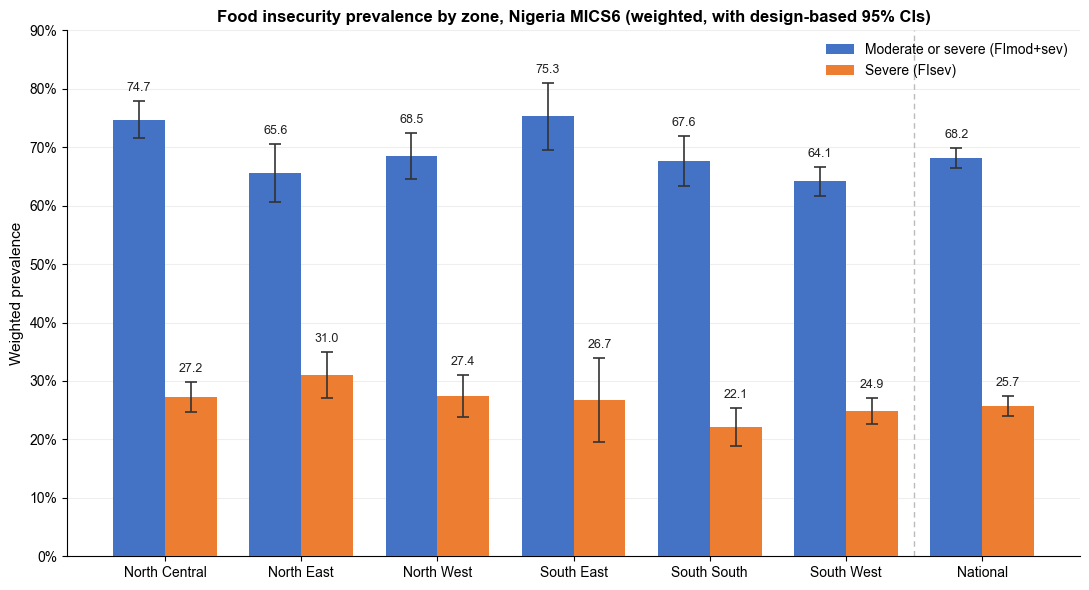

In [140]:
"""
Food insecurity prevalence by zone, with design-based 95% CIs.

Reads mics6_fi_by_zone.csv (columns: zone, indicator, proportion, ci_low,
ci_high, global_p) and produces a grouped bar chart with error bars, value
labels, the national average, and the global design-based test p-value.
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

plt.rcParams.update(
    {
        "font.family": "Arial",
        "font.sans-serif": ["Arial"],
        "axes.labelsize": 11,
        "axes.titlesize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
    }
)

CSV = "../../../../mics6_fi_by_zone.csv"
OUT = "fi_by_zone.png"

# ---- data ----
df = pd.read_csv(CSV)
order = [
    "North Central",
    "North East",
    "North West",
    "South East",
    "South South",
    "South West",
    "National",
]
inds = {"prob_mod_sev": "Moderate or severe (FImod+sev)", "prob_sev": "Severe (FIsev)"}
colors = {"prob_mod_sev": "#4472C4", "prob_sev": "#ED7D31"}

df["zone"] = pd.Categorical(df["zone"], categories=order, ordered=True)
df = df.sort_values(["indicator", "zone"])

x = np.arange(len(order))
width = 0.38

fig, ax = plt.subplots(figsize=(11, 6))

for k, (ind, label) in enumerate(inds.items()):
    sub = df[df["indicator"] == ind].set_index("zone").loc[order]
    prop = sub["proportion"].values
    # asymmetric error-bar lengths from the CI bounds
    err = np.vstack([prop - sub["ci_low"].values, sub["ci_high"].values - prop])
    offset = (k - 0.5) * width
    bars = ax.bar(x + offset, prop, width, label=label, color=colors[ind], zorder=3)
    ax.errorbar(
        x + offset,
        prop,
        yerr=err,
        fmt="none",
        ecolor="#333333",
        elinewidth=1.2,
        capsize=4,
        capthick=1.2,
        zorder=4,
    )
    # value labels above the upper CI
    for xi, p, hi in zip(x + offset, prop, sub["ci_high"].values):
        ax.text(
            xi,
            hi + 1.2,
            f"{p:.1f}",
            ha="center",
            va="bottom",
            fontsize=9,
            color="#222222",
        )

# separate the National group with a light divider
ax.axvline(x=len(order) - 1.5, color="#BBBBBB", lw=1, ls=(0, (4, 3)), zorder=1)

# global design-based test p-values (one per indicator)
pvals = df.groupby("indicator")["global_p"].first()


def fmt_p(p):
    return "p < 0.001" if p < 0.001 else f"p = {p:.3f}"


# ptxt = (
#     "Design-based test of regional variation:\n"
#     f"  Moderate or severe: {fmt_p(pvals['prob_mod_sev'])}\n"
#     f"  Severe: {fmt_p(pvals['prob_sev'])}"
# )
# ax.text(
#     0.015,
#     0.97,
#     ptxt,
#     transform=ax.transAxes,
#     va="top",
#     ha="left",
#     fontsize=9,
#     color="#333333",
#     bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#CCCCCC", lw=0.8),
# )

ax.set_xticks(x)
ax.set_xticklabels(order, fontsize=10)
ax.set_ylim(0, 90)
ax.yaxis.set_major_formatter(PercentFormatter())
ax.set_ylabel("Weighted prevalence")
ax.set_title(
    "Food insecurity prevalence by zone, Nigeria MICS6 "
    "(weighted, with design-based 95% CIs)",
    fontsize=12,
    fontweight="bold",
)
ax.legend(loc="upper right", frameon=False, fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#EEEEEE", zorder=0)
ax.set_axisbelow(True)

fig.tight_layout()
fig.savefig(OUT, dpi=300, bbox_inches="tight")
print("wrote", OUT)

In [141]:
df.head()

,zone,indicator,proportion,ci_low,ci_high,global_p
0,North Central,prob_mod_sev,74.728753,71.592870,77.864637,0.000004
1,North East,prob_mod_sev,65.602207,60.592113,70.612300,0.000004
2,North West,prob_mod_sev,68.485975,64.547662,72.424288,0.000004
3,South East,prob_mod_sev,75.273935,69.515646,81.032224,0.000004
4,South South,prob_mod_sev,67.597466,63.325011,71.869921,0.000004
